In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow.keras import Sequential, callbacks, optimizers
from tensorflow.keras import layers, Model

In [2]:
# Set the seeds for reproducibility
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [15, 10]
batch_size = 32
validation_split = 0.2
image_size = (128, 128)

# Mapping

In [3]:
mapping = {
    '0': '1 Cent',
    '1': '2 Cent',
    '2': '5 Cent',
    '3': '10 Cent',
    '4': '20 Cent',
    '5': '50 Cent',
    '6': '1 Euro',
    '7': '2 Euro',
}

# Visualizations

In [4]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(131), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])

    plt.subplot(132), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    plt.subplot(133), plt.plot(epochs, h['f1_macro'], '.-',
                               epochs, h['val_f1_macro'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('F1 Macro')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

In [5]:
path_to_dataset = '../../data/coin_tf_dataset'

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path_to_dataset,
    image_size=image_size,
    color_mode="rgb",
    batch_size=batch_size,
    validation_split=validation_split,
    seed=42,
    subset="training",
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path_to_dataset,
    image_size=image_size,
    color_mode="rgb",
    batch_size=batch_size,
    validation_split=validation_split,
    seed=42,
    subset="validation",
    label_mode="categorical"
)

Found 336 files belonging to 8 classes.
Using 269 files for training.
Found 336 files belonging to 8 classes.
Using 67 files for validation.


In [7]:
class_names = val_ds.class_names  # or train_ds.class_names (same ordering)
num_classes = len(class_names)

['0', '1', '2', '3', '4', '5', '6', '7'] 8


In [8]:
y_train = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in train_ds], axis=0)
y_val   = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds], axis=0)

# counts = np.bincount(y_train, minlength=num_classes) + np.bincount(y_val, minlength=num_classes)

counts = np.bincount(y_train, minlength=num_classes)  # train only


total = counts.sum()
weights = total / (len(counts) * counts)       # inverse frequency
class_weight = {i: float(weights[i]) for i in range(len(counts))}

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# Data Augmentation Block

In [ ]:
def _solve_homography(src_xy, dst_xy):
    # src_xy, dst_xy: [4, 2]
    src_xy = tf.cast(src_xy, tf.float32)
    dst_xy = tf.cast(dst_xy, tf.float32)

    src_xy = tf.ensure_shape(src_xy, [4, 2])
    dst_xy = tf.ensure_shape(dst_xy, [4, 2])

    x = src_xy[:, 0]
    y = src_xy[:, 1]
    u = dst_xy[:, 0]
    v = dst_xy[:, 1]

    zeros = tf.zeros_like(x)
    ones = tf.ones_like(x)

    a1 = tf.stack([x, y, ones, zeros, zeros, zeros, -u * x, -u * y], axis=1)
    a2 = tf.stack([zeros, zeros, zeros, x, y, ones, -v * x, -v * y], axis=1)

    A = tf.reshape(tf.stack([a1, a2], axis=1), [8, 8])
    b = tf.reshape(tf.stack([u, v], axis=1), [8, 1])

    h = tf.linalg.solve(A, b)[:, 0]
    H = tf.reshape(
        tf.stack([
            h[0], h[1], h[2],
            h[3], h[4], h[5],
            h[6], h[7], 1.0
        ]),
        [3, 3]
    )
    return H


def _projective_transform_from_corners(src_xy, dst_xy):
    # ImageProjectiveTransformV3 expects output->input mapping
    H_src_to_dst = _solve_homography(src_xy, dst_xy)
    H_dst_to_src = tf.linalg.inv(H_src_to_dst)
    H_dst_to_src = H_dst_to_src / H_dst_to_src[2, 2]

    return tf.stack([
        H_dst_to_src[0, 0], H_dst_to_src[0, 1], H_dst_to_src[0, 2],
        H_dst_to_src[1, 0], H_dst_to_src[1, 1], H_dst_to_src[1, 2],
        H_dst_to_src[2, 0], H_dst_to_src[2, 1]
    ])


def _warp_image_with_corners(image, dst_xy, fill_value=255.0):
    image = tf.cast(image, tf.float32)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    src_xy = tf.cast([
        [0.0, 0.0],
        [tf.cast(w - 1, tf.float32), 0.0],
        [tf.cast(w - 1, tf.float32), tf.cast(h - 1, tf.float32)],
        [0.0, tf.cast(h - 1, tf.float32)],
    ], tf.float32)

    transform = _projective_transform_from_corners(src_xy, dst_xy)[None, :]

    warped = tf.raw_ops.ImageProjectiveTransformV3(
        images=image[None, ...],
        transforms=transform,
        output_shape=tf.stack([h, w]),
        interpolation="BILINEAR",
        fill_mode="CONSTANT",
        fill_value=tf.cast(fill_value, tf.float32),
    )
    return warped[0]


class RandomBrightness255(layers.Layer):
    # max_delta is a fraction of 255, e.g. 0.10 => +/-25.5 intensity
    def __init__(self, max_delta=0.12, **kwargs):
        super().__init__(**kwargs)
        self.max_delta = float(max_delta)

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x
        delta = tf.random.uniform([], -self.max_delta, self.max_delta) * 255.0
        return x + delta

    def compute_output_shape(self, input_shape):
        return input_shape


class AddGaussianNoise255(layers.Layer):
    # stddev is in pixel units for images in [0, 255]
    def __init__(self, stddev=3.0, **kwargs):
        super().__init__(**kwargs)
        self.stddev = float(stddev)

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x
        noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=self.stddev, dtype=tf.float32)
        return x + noise

    def compute_output_shape(self, input_shape):
        return input_shape


class RandomGamma(layers.Layer):
    # Camera-like exposure / auto-adjust changes
    def __init__(self, gamma_range=(0.85, 1.20), gain_range=(0.95, 1.05), **kwargs):
        super().__init__(**kwargs)
        self.gamma_range = gamma_range
        self.gain_range = gain_range

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x

        gamma = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
        gain = tf.random.uniform([], self.gain_range[0], self.gain_range[1])

        x01 = tf.clip_by_value(x / 255.0, 0.0, 1.0)
        x01 = tf.image.adjust_gamma(x01, gamma=gamma, gain=gain)
        return x01 * 255.0

    def compute_output_shape(self, input_shape):
        return input_shape


class RandomWebcamTablePerspective(layers.Layer):
    """
    Realistic projective augmentation for a camera looking at an object on a table.
    Main effect:
      - downward tilt around X axis (~30°)
      - small left/right yaw
      - small in-plane roll
      - small zoom / translation
    """

    def __init__(
        self,
        p=0.90,
        tilt_range_deg=(22.0, 35.0),
        yaw_range_deg=(-10.0, 10.0),
        roll_range_deg=(-5.0, 5.0),
        zoom_range=(0.92, 1.08),
        shift_range=0.08,
        camera_distance_range=(2.6, 3.6),
        fill_value=255.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.p = float(p)
        self.tilt_range_deg = tilt_range_deg
        self.yaw_range_deg = yaw_range_deg
        self.roll_range_deg = roll_range_deg
        self.zoom_range = zoom_range
        self.shift_range = float(shift_range)
        self.camera_distance_range = camera_distance_range
        self.fill_value = float(fill_value)

    @staticmethod
    def _deg2rad(x):
        return x * (tf.constant(3.141592653589793, tf.float32) / 180.0)

    def _make_rotation(self, tilt_deg, yaw_deg, roll_deg):
        ax = self._deg2rad(tilt_deg)
        ay = self._deg2rad(yaw_deg)
        az = self._deg2rad(roll_deg)

        cx, sx = tf.cos(ax), tf.sin(ax)
        cy, sy = tf.cos(ay), tf.sin(ay)
        cz, sz = tf.cos(az), tf.sin(az)

        Rx = tf.stack([
            [1.0, 0.0, 0.0],
            [0.0, cx, -sx],
            [0.0, sx, cx],
        ])

        Ry = tf.stack([
            [cy, 0.0, sy],
            [0.0, 1.0, 0.0],
            [-sy, 0.0, cy],
        ])

        Rz = tf.stack([
            [cz, -sz, 0.0],
            [sz, cz, 0.0],
            [0.0, 0.0, 1.0],
        ])

        return Rz @ Ry @ Rx

    def _augment_impl(self, image):
        image = tf.cast(image, tf.float32)
        h = tf.cast(tf.shape(image)[0], tf.float32)
        w = tf.cast(tf.shape(image)[1], tf.float32)

        tilt = tf.random.uniform([], self.tilt_range_deg[0], self.tilt_range_deg[1])
        yaw = tf.random.uniform([], self.yaw_range_deg[0], self.yaw_range_deg[1])
        roll = tf.random.uniform([], self.roll_range_deg[0], self.roll_range_deg[1])
        zoom = tf.random.uniform([], self.zoom_range[0], self.zoom_range[1])
        tx = tf.random.uniform([], -self.shift_range, self.shift_range)
        ty = tf.random.uniform([], -self.shift_range, self.shift_range)
        cam_dist = tf.random.uniform([], self.camera_distance_range[0], self.camera_distance_range[1])

        corners_3d = tf.constant([
            [-1.0, -1.0, 0.0],
            [ 1.0, -1.0, 0.0],
            [ 1.0,  1.0, 0.0],
            [-1.0,  1.0, 0.0],
        ], dtype=tf.float32)

        R = self._make_rotation(tilt, yaw, roll)
        rotated = tf.transpose(R @ tf.transpose(corners_3d))

        z = rotated[:, 2] + cam_dist
        xy = rotated[:, :2] / z[:, None]

        xy_centered = xy - tf.reduce_mean(xy, axis=0, keepdims=True)
        max_abs = tf.reduce_max(tf.abs(xy_centered)) + 1e-6
        xy_norm = xy_centered / (2.0 * max_abs) + 0.5

        xy_norm = (xy_norm - 0.5) * zoom + tf.constant([0.5, 0.5], dtype=tf.float32)
        xy_norm = xy_norm + tf.stack([tx, ty])[None, :]
        xy_norm = tf.clip_by_value(xy_norm, 0.02, 0.98)

        dst_xy = xy_norm * tf.stack([w - 1.0, h - 1.0])[None, :]
        return _warp_image_with_corners(image, dst_xy, fill_value=self.fill_value)

    def _augment_one(self, image):
        apply_aug = tf.random.uniform([]) < self.p
        return tf.cond(
            apply_aug,
            lambda: self._augment_impl(image),
            lambda: tf.cast(image, tf.float32)
        )

    def call(self, inputs, training=None):
        x = tf.cast(inputs, tf.float32)
        if training is False:
            return x

        image_spec = tf.TensorSpec(
            shape=(x.shape[1], x.shape[2], x.shape[3]),
            dtype=tf.float32
        )

        y = tf.map_fn(
            self._augment_one,
            x,
            fn_output_signature=image_spec
        )

        y = tf.ensure_shape(y, x.shape)
        return y

    def compute_output_shape(self, input_shape):
        return input_shape


data_augmentation = Sequential([
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=0.04, fill_mode="constant", fill_value=255.0),
    layers.RandomTranslation(height_factor=0.04, width_factor=0.04, fill_mode="constant", fill_value=255.0),
    layers.RandomZoom(height_factor=(-0.08, 0.06), width_factor=(-0.08, 0.06), fill_mode="constant", fill_value=255.0),

    RandomWebcamTablePerspective(
        p=0.95,
        # tilt_range_deg=(10.0, 18.0)   # weak perspective
        # tilt_range_deg=(25.0, 35.0)   # good realistic ~30° webcam view
        tilt_range_deg=(35.0, 50.0),   # very strong perspective
        # yaw_range_deg=(-8.0, 8.0),
        # yaw_range_deg=(-3.0, 3.0)    # almost straight
        # yaw_range_deg=(-8.0, 8.0)    # realistic small side variation
        yaw_range_deg=(-15.0, 15.0),  # stronger left/right skew

        roll_range_deg=(-4.0, 4.0),
        zoom_range=(0.95, 1.08),
        shift_range=0.06,
        camera_distance_range=(2.2, 2.8),   # stronger perspective
       # camera_distance_range=(2.8, 3.4),   # balanced realistic
       # camera_distance_range=(4.0, 5.0),   # flatter view

        fill_value=255.0,
    ),

    RandomBrightness255(max_delta=0.10),
    layers.RandomContrast(factor=0.15),
    RandomGamma(gamma_range=(0.90, 1.15), gain_range=(0.97, 1.03)),
    AddGaussianNoise255(stddev=2.5),
], name="coin_webcam_augmentation")

# Built Model ( ImageNet )

In [11]:
num_classes = 8
base = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False  # first stage: train only the head

inputs = layers.Input((128,128,3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
# x = layers.RandomFlip("horizontal")(x)
# x = layers.RandomRotation(0.05)(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

# Epoch 100/100
# 9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step - accuracy: 0.8625 - f1_macro: 0.8595 - loss: 1.1329 - top_k_categorical_accuracy: 0.9963 - val_accuracy: 0.8060 - val_f1_macro: 0.7954 - val_loss: 1.2184 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.0000e-04


# Compile Model

In [15]:
model.compile(
    optimizer=optimizers.AdamW(learning_rate=1e-4,
                               weight_decay=1e-5
                               ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.2  # helps generalization; try 0.0–0.1
    ),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.F1Score(average="macro", name="f1_macro"),
        "top_k_categorical_accuracy",
    ],
)

# Callbacks

In [16]:
# EarlyStopping
early_stop_cb = callbacks.EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True)
# Learning Rate Callback
lr_optimizer = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)
checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="../../models/tensorflow/best_model.keras",
    save_best_only=True,
    mode='max',
    monitor='val_accuracy'
)

# Training

In [17]:
epochs = 200

history = model.fit(train_ds,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=val_ds,
                    class_weight=class_weight,   # ← your computed weights
                    callbacks=[early_stop_cb, lr_optimizer, checkpoint_callback])

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 561ms/step - accuracy: 0.1413 - f1_macro: 0.1090 - loss: 2.9477 - top_k_categorical_accuracy: 0.7212 - val_accuracy: 0.1940 - val_f1_macro: 0.0952 - val_loss: 2.4533 - val_top_k_categorical_accuracy: 0.7015 - learning_rate: 1.0000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.1710 - f1_macro: 0.1449 - loss: 2.6887 - top_k_categorical_accuracy: 0.7472 - val_accuracy: 0.1940 - val_f1_macro: 0.1144 - val_loss: 2.2921 - val_top_k_categorical_accuracy: 0.7313 - learning_rate: 1.0000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.1673 - f1_macro: 0.1392 - loss: 2.6908 - top_k_categorical_accuracy: 0.7175 - val_accuracy: 0.2239 - val_f1_macro: 0.1669 - val_loss: 2.1652 - val_top_k_categorical_accuracy: 0.7761 - learning_rate: 1.0000e-04
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.1487 - f1_macro: 0.1244 - loss: 2.4701 - top_k_categorical_accuracy: 0.7249 - val_accuracy: 0.2687 - val_f1_m

 # Plot History ( training vs test )

Train Acc      0.8624535202980042
Validation Acc 0.8059701323509216


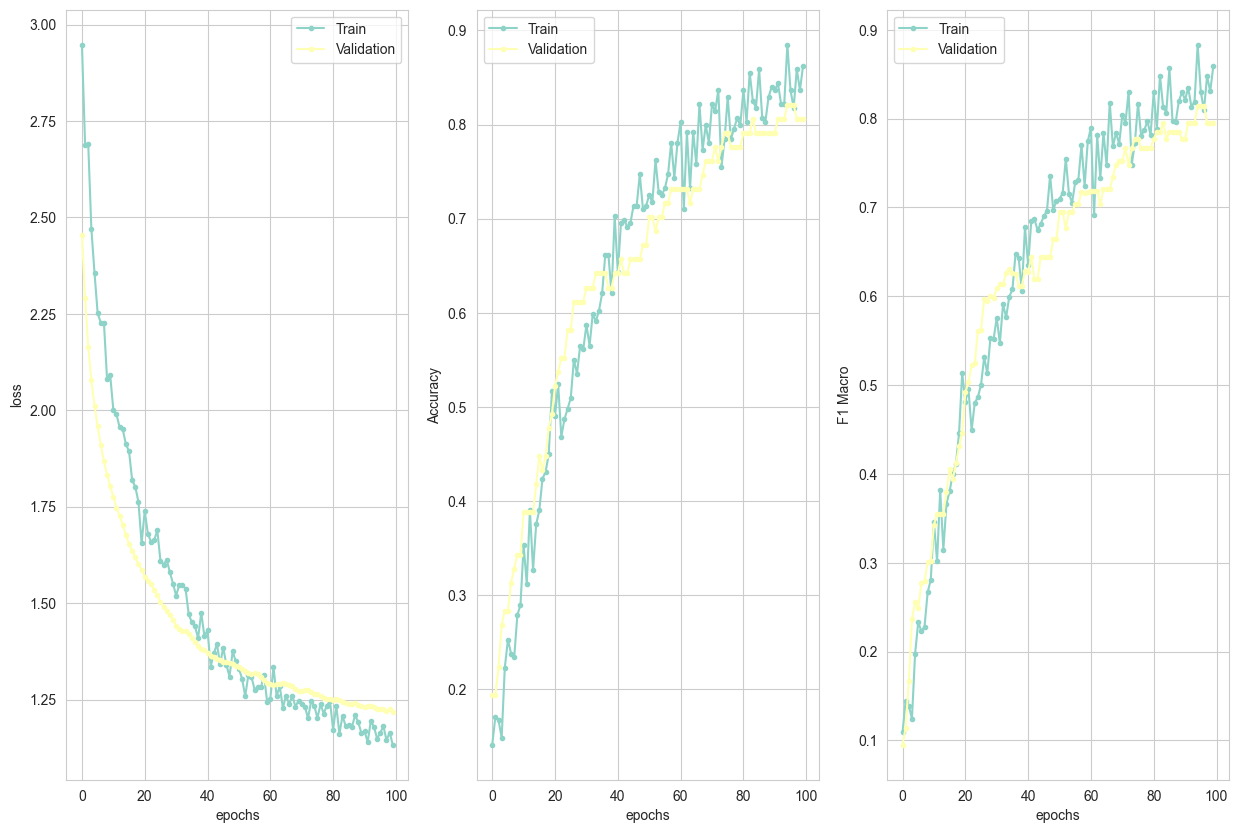

In [18]:
plot_history(history)

In [19]:
import numpy as np

y_train = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in train_ds], axis=0)
y_val   = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds], axis=0)

print("train counts:", np.bincount(y_train, minlength=num_classes))
print("val counts:  ", np.bincount(y_val, minlength=num_classes))

train counts: [36 38 49 25 39 21 40 21]
val counts:   [ 5 13  7  7 11  6 11  7]


In [20]:
total_distribution = np.bincount(y_train, minlength=num_classes) + np.bincount(y_val, minlength=num_classes)

In [21]:
num_classes = len(class_names)
display_labels = [mapping[name] for name in class_names]

In [22]:

# Predict on validation dataset
y_prob = model.predict(val_ds)

# predicted class ids
y_pred = np.argmax(y_prob, axis=1)

# true class ids from val_ds (one-hot -> argmax)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds], axis=0)

conf_mtx = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 976ms/step


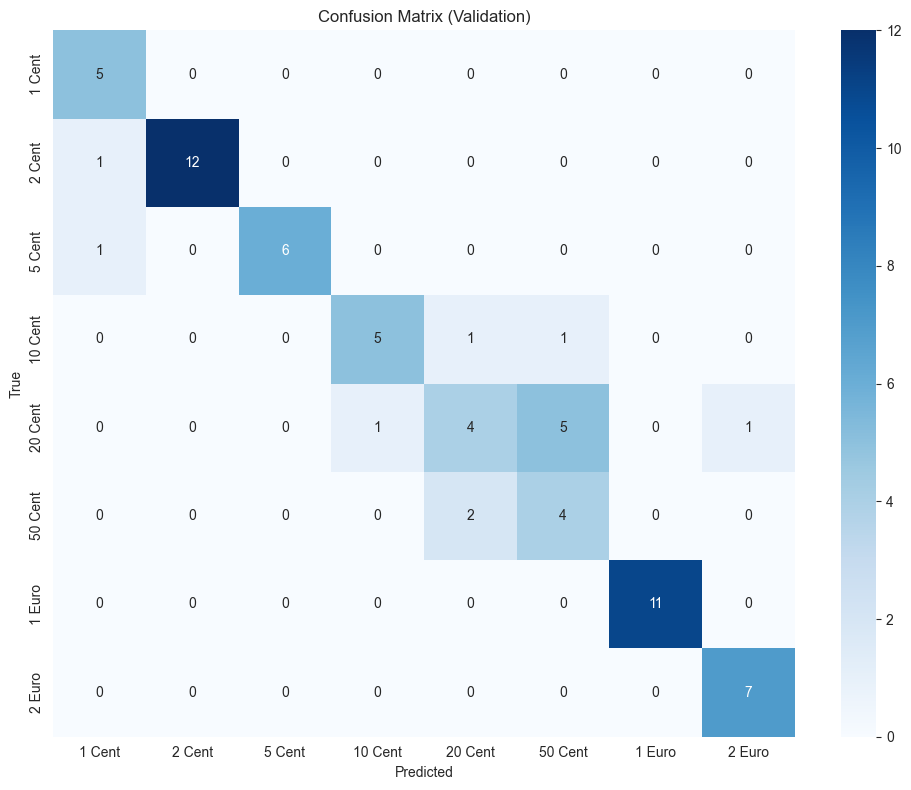

In [23]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    conf_mtx,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_labels,
    yticklabels=display_labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()

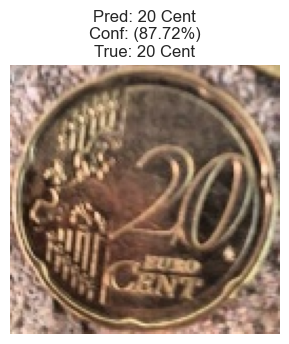

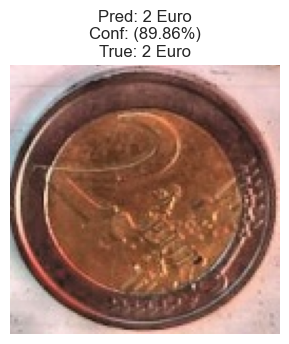

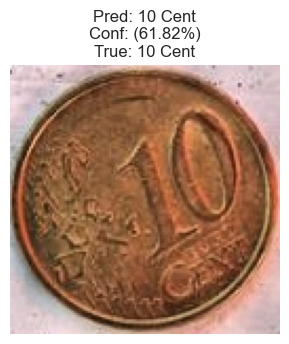

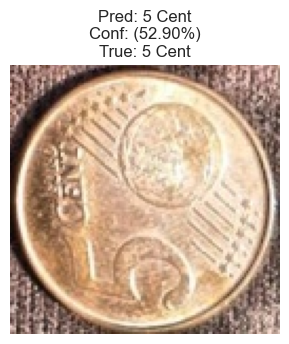

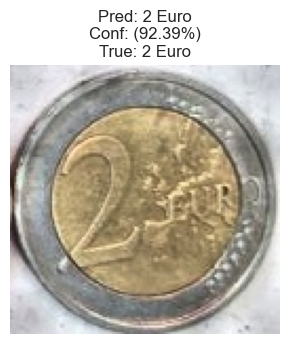

In [24]:
# Ensure your mapping keys match folder names '0'..'7'
idx_to_name = {int(k): v for k, v in mapping.items()}

def predict_one_image(path, model, image_size=(128, 128)):
    img = tf.keras.utils.load_img(path, target_size=image_size)  # PIL
    x = tf.keras.utils.img_to_array(img)                         # float32, range 0..255
    x = np.expand_dims(x, axis=0)                                # (1,H,W,3)

    probs = model.predict(x, verbose=0)[0]                       # (8,)
    pred_idx = int(np.argmax(probs))
    pred_name = idx_to_name.get(pred_idx, str(pred_idx))
    return pred_idx, pred_name, probs, img

for _ in range(5):
    # Your dataset folders are '0'..'7', so include 0 and 7:
    coin_folder = np.random.randint(0, 8)   # 0..7 inclusive
    coin_img = np.random.randint(1, 25)     # adjust if some folders have fewer/more images

    img_path = f"../../data/coin_tf_dataset/{coin_folder}/{coin_img}.jpg"

    pred_idx, pred_name, probs, img = predict_one_image(img_path, model, image_size=image_size)

    plt.figure(figsize=(3.5, 3.5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {pred_name}\nConf: ({probs[pred_idx]:.2%})\nTrue: {mapping[str(coin_folder)]}")
    plt.show()